<a href="https://colab.research.google.com/github/adalbertii/Track-optimization/blob/main/VRP_with_visualisation_08_06_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 18.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 w

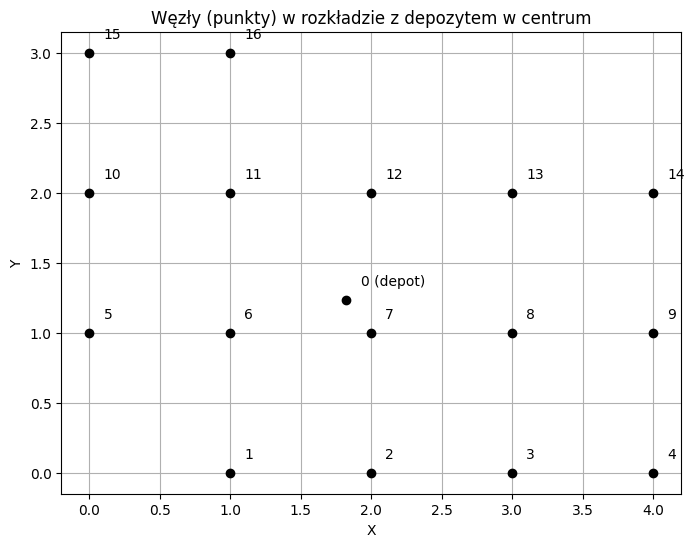

Objective: 162116
Route for vehicle 0:
 0 ->  8 ->  2 ->  6 ->  5 -> 0
Distance of the route: 1552m

Route for vehicle 1:
 0 ->  7 ->  1 ->  4 ->  3 -> 0
Distance of the route: 1552m

Route for vehicle 2:
 0 ->  13 -> 0
Distance of the route: 708m

Route for vehicle 3:
 0 ->  11 ->  15 ->  12 -> 0
Distance of the route: 1552m

Route for vehicle 4:
 0 ->  9 ->  10 ->  16 ->  14 -> 0
Distance of the route: 1552m

Maximum of the route distances: 1552m


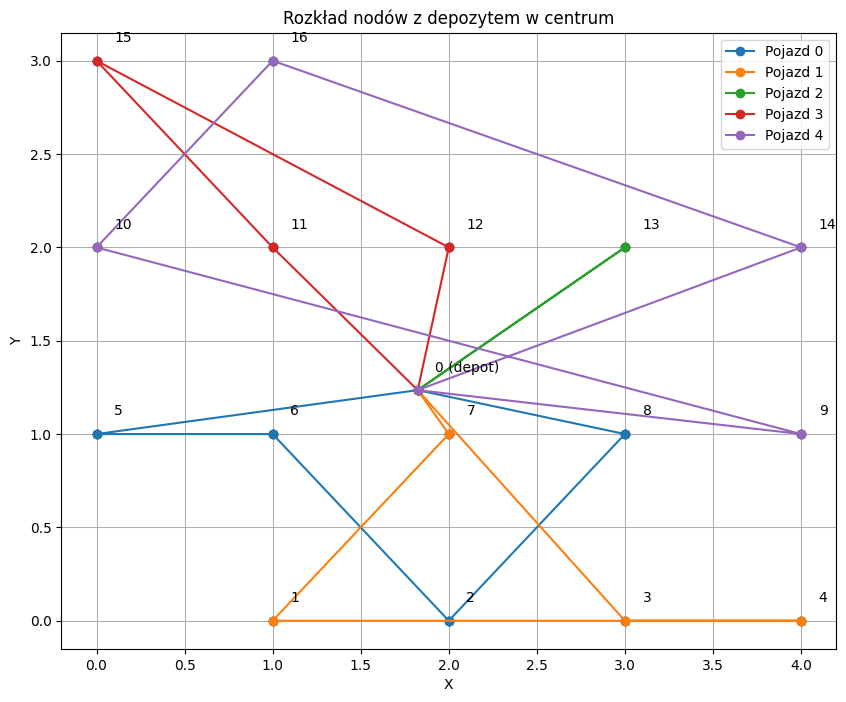

In [3]:
"""Simple Vehicles Routing Problem (VRP).

This is a sample using the routing library python wrapper to solve a VRP
problem.
A description of the problem can be found here:
http://en.wikipedia.org/wiki/Vehicle_routing_problem.

Distances are in meters.
"""

from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp



def create_data_model():
    """Stores the data for the problem."""
    data = {}
    data["distance_matrix"] = [
        # fmt: off
      [0, 548, 776, 696, 582, 274, 502, 194, 308, 194, 536, 502, 388, 354, 468, 776, 662],
      [548, 0, 684, 308, 194, 502, 730, 354, 696, 742, 1084, 594, 480, 674, 1016, 868, 1210],
      [776, 684, 0, 992, 878, 502, 274, 810, 468, 742, 400, 1278, 1164, 1130, 788, 1552, 754],
      [696, 308, 992, 0, 114, 650, 878, 502, 844, 890, 1232, 514, 628, 822, 1164, 560, 1358],
      [582, 194, 878, 114, 0, 536, 764, 388, 730, 776, 1118, 400, 514, 708, 1050, 674, 1244],
      [274, 502, 502, 650, 536, 0, 228, 308, 194, 240, 582, 776, 662, 628, 514, 1050, 708],
      [502, 730, 274, 878, 764, 228, 0, 536, 194, 468, 354, 1004, 890, 856, 514, 1278, 480],
      [194, 354, 810, 502, 388, 308, 536, 0, 342, 388, 730, 468, 354, 320, 662, 742, 856],
      [308, 696, 468, 844, 730, 194, 194, 342, 0, 274, 388, 810, 696, 662, 320, 1084, 514],
      [194, 742, 742, 890, 776, 240, 468, 388, 274, 0, 342, 536, 422, 388, 274, 810, 468],
      [536, 1084, 400, 1232, 1118, 582, 354, 730, 388, 342, 0, 878, 764, 730, 388, 1152, 354],
      [502, 594, 1278, 514, 400, 776, 1004, 468, 810, 536, 878, 0, 114, 308, 650, 274, 844],
      [388, 480, 1164, 628, 514, 662, 890, 354, 696, 422, 764, 114, 0, 194, 536, 388, 730],
      [354, 674, 1130, 822, 708, 628, 856, 320, 662, 388, 730, 308, 194, 0, 342, 422, 536],
      [468, 1016, 788, 1164, 1050, 514, 514, 662, 320, 274, 388, 650, 536, 342, 0, 764, 194],
      [776, 868, 1552, 560, 674, 1050, 1278, 742, 1084, 810, 1152, 274, 388, 422, 764, 0, 798],
      [662, 1210, 754, 1358, 1244, 708, 480, 856, 514, 468, 354, 844, 730, 536, 194, 798, 0],
        # fmt: on
    ]
    data["num_vehicles"] = 5
    data["depot"] = 0
    return data



def visualize_nodes(data):
    """Wizualizacja wszystkich węzłów, z depozytem w centrum."""
    # Generujemy przykładowe współrzędne dla każdego węzła
    coords = {}
    for idx in range(len(data["distance_matrix"])):
        coords[idx] = (idx % 5, idx // 5)  # przykładowe współrzędne

    # Obliczamy średnią pozycję wszystkich punktów, aby znaleźć centrum
    x_coords = [coord[0] for coord in coords.values()]
    y_coords = [coord[1] for coord in coords.values()]
    centroid_x = sum(x_coords) / len(x_coords)
    centroid_y = sum(y_coords) / len(y_coords)

    # Zamieniamy współrzędną depozytu na centrum
    coords[data["depot"]] = (centroid_x, centroid_y)

    plt.figure(figsize=(8, 6))
    for node, (x, y) in coords.items():
        plt.plot(x, y, 'ko')  # punkt
        label = f"{node} (depot)" if node == data["depot"] else str(node)
        plt.text(x + 0.1, y + 0.1, label)
    plt.title('Węzły (punkty) w rozkładzie z depozytem w centrum')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.show()

def print_solution(data, manager, routing, solution):
    """Prints solution on console."""
    print(f"Objective: {solution.ObjectiveValue()}")
    max_route_distance = 0
    for vehicle_id in range(data["num_vehicles"]):
        if not routing.IsVehicleUsed(solution, vehicle_id):
            continue
        index = routing.Start(vehicle_id)
        plan_output = f"Route for vehicle {vehicle_id}:\n"
        route_distance = 0
        while not routing.IsEnd(index):
            plan_output += f" {manager.IndexToNode(index)} -> "
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(
                previous_index, index, vehicle_id
            )
        plan_output += f"{manager.IndexToNode(index)}\n"
        plan_output += f"Distance of the route: {route_distance}m\n"
        print(plan_output)
        max_route_distance = max(route_distance, max_route_distance)
    print(f"Maximum of the route distances: {max_route_distance}m")

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

def visualize_solution(data, manager, routing, solution):
    """Wizualizacja tras pojazdów z depozytem w centrum rozkładu nodów."""
    import matplotlib.pyplot as plt

    # Generujemy przykładowe współrzędne dla nodów
    coords = {}
    for idx in range(len(data["distance_matrix"])):
        coords[idx] = (idx % 5, idx // 5)

    # Obliczamy środek rozkładu wszystkich nodów
    x_coords = [coord[0] for coord in coords.values()]
    y_coords = [coord[1] for coord in coords.values()]
    centroid_x = sum(x_coords) / len(x_coords)
    centroid_y = sum(y_coords) / len(y_coords)

    # Ustawiamy depozyt w centrum
    coords[data["depot"]] = (centroid_x, centroid_y)

    plt.figure(figsize=(10, 8))
    # Rysujemy wszystkie nodów
    for node, (x, y) in coords.items():
        plt.plot(x, y, 'ko')
        label = f"{node} (depot)" if node == data["depot"] else str(node)
        plt.text(x + 0.1, y + 0.1, label)

    # Rysujemy trasy pojazdów
    for vehicle_id in range(data["num_vehicles"]):
        if not routing.IsVehicleUsed(solution, vehicle_id):
            continue
        index = routing.Start(vehicle_id)
        route_x = []
        route_y = []
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            x, y = coords[node_index]
            route_x.append(x)
            route_y.append(y)
            index = solution.Value(routing.NextVar(index))
        # Dodaj końcowy nod
        node_index = manager.IndexToNode(index)
        x, y = coords[node_index]
        route_x.append(x)
        route_y.append(y)
        plt.plot(route_x, route_y, marker='o', label=f'Pojazd {vehicle_id}')

    plt.title('Rozkład nodów z depozytem w centrum')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True)
    plt.show()
def main():
    """Entry point of the program."""
    # Instantiate the data problem.
    data = create_data_model()

    # Create the routing index manager.
    manager = pywrapcp.RoutingIndexManager(
        len(data["distance_matrix"]), data["num_vehicles"], data["depot"]
    )

    # Create Routing Model.
    routing = pywrapcp.RoutingModel(manager)

    # Create and register a transit callback.
    def distance_callback(from_index, to_index):
        """Returns the distance between the two nodes."""
        # Convert from routing variable Index to distance matrix NodeIndex.
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data["distance_matrix"][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)

    # Define cost of each arc.
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Add Distance constraint.
    dimension_name = "Distance"
    routing.AddDimension(
        transit_callback_index,
        0,  # no slack
        3000,  # vehicle maximum travel distance
        True,  # start cumul to zero
        dimension_name,
    )
    distance_dimension = routing.GetDimensionOrDie(dimension_name)
    distance_dimension.SetGlobalSpanCostCoefficient(100)

    # Setting first solution heuristic.
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )


    visualize_nodes(data)


    # Solve the problem.
    solution = routing.SolveWithParameters(search_parameters)


    # Print solution on console.
    if solution:
        print_solution(data, manager, routing, solution)
        visualize_solution(data, manager, routing, solution)
    else:
        print("No solution found !")


if __name__ == "__main__":
    main()